# Tutorial 07 — Doppler + polarimetric spectra of rain at X-band

Profilers, cloud radars, and modern disdrometers measure *spectra*
— the Doppler-velocity-resolved version of the polarimetric
observables. The spectrum of a falling rain PSD is a change of
variable from drop diameter to terminal velocity, convolved with
turbulence and smeared by finite antenna beamwidth. This notebook
walks through the four knobs that shape the spectrum and checks
that the integrated spectral matrices round-trip to the bulk
`radar.*` observables.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rustmatrix import Scatterer, SpectralIntegrator, radar, spectra
from rustmatrix.psd import GammaPSD, PSDIntegrator
from rustmatrix.refractive import m_w_10C
from rustmatrix.tmatrix_aux import (K_w_sqr, dsr_thurai_2007,
                                      geom_vert_back, geom_vert_forw,
                                      wl_X)


## Build an X-band rain scatterer with vertical-pointing geometry


In [2]:
def build_rain():
    s = Scatterer(wavelength=wl_X, m=m_w_10C[wl_X],
                  Kw_sqr=K_w_sqr[wl_X], ddelt=1e-4, ndgs=2)
    integ = PSDIntegrator()
    integ.D_max = 6.0
    integ.num_points = 64
    integ.axis_ratio_func = lambda D: 1.0 / dsr_thurai_2007(D)
    integ.geometries = (geom_vert_back, geom_vert_forw)
    s.psd_integrator = integ
    s.psd_integrator.init_scatter_table(s)
    s.psd = GammaPSD(D0=1.5, Nw=8e3, mu=4, D_max=6.0)
    return s

rain = build_rain()


## Four configurations of the spectrum

1. No turbulence, no beam broadening — delta-function binning.
2. Gaussian turbulence σ = 0.5 m/s — classical broadening.
3. Zeng 2023 particle-inertia turbulence.
4. Beam broadening with u_h = 8 m/s and θ_b = 1°.


In [3]:
def run_config(turbulence, u_h=0.0, beamwidth=0.0):
    integ = SpectralIntegrator(
        rain,
        fall_speed=spectra.fall_speed.atlas_srivastava_sekhon_1973,
        turbulence=turbulence,
        v_min=-1.0, v_max=12.0, n_bins=1024,
        u_h=u_h, beamwidth=beamwidth,
        geometry_backscatter=geom_vert_back,
        geometry_forward=geom_vert_forw,
    )
    return integ.run()

configs = {
    'no turbulence': run_config(spectra.NoTurbulence()),
    'Gaussian σ=0.5': run_config(spectra.GaussianTurbulence(0.5)),
    'Zeng 2023 ε=1e-3': run_config(
        spectra.InertialZeng2023(sigma_air=0.5, epsilon=1e-3)),
    'beam (u_h=8, θ_b=1°)': run_config(
        spectra.NoTurbulence(),
        u_h=8.0, beamwidth=np.deg2rad(1.0)),
}

rain.set_geometry(geom_vert_back)
Zh_bulk = radar.refl(rain)
for name, res in configs.items():
    Zh_int = np.trapezoid(res.sZ_h, res.v)
    print(f'{name:<24} ∫sZ_h dv / Z_h_bulk - 1 = '
          f'{(Zh_int - Zh_bulk) / Zh_bulk:+.2e}')


no turbulence            ∫sZ_h dv / Z_h_bulk - 1 = +1.27e-16
Gaussian σ=0.5           ∫sZ_h dv / Z_h_bulk - 1 = -1.58e-10
Zeng 2023 ε=1e-3         ∫sZ_h dv / Z_h_bulk - 1 = -1.58e-10
beam (u_h=8, θ_b=1°)     ∫sZ_h dv / Z_h_bulk - 1 = +1.27e-16


/var/folders/hl/905j06p96s1bqggj89x1kg9r0000gq/T/ipykernel_51009/779762332.py:11: UserWarning: Spectral power extends beyond v_bins: expected range [-1.59, 10.9] m/s, v_bins covers [-1, 12] m/s. Bulk-sum identity will be degraded by the leakage.
  return integ.run()


## Plot sZ_h(v) for the four configurations


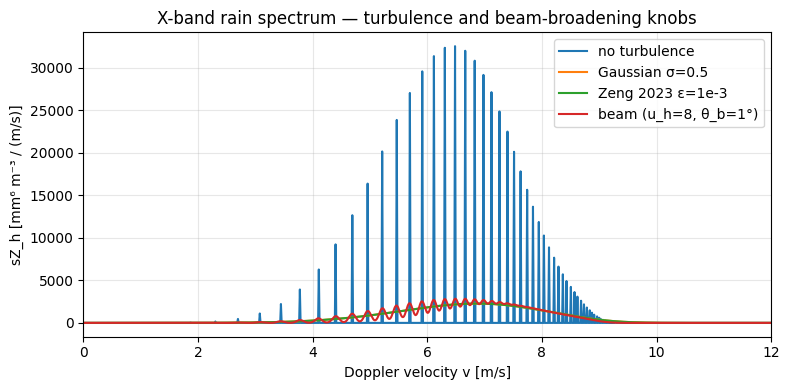

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, res in configs.items():
    ax.plot(res.v, res.sZ_h, label=name)
ax.set_xlabel('Doppler velocity v [m/s]')
ax.set_ylabel('sZ_h [mm⁶ m⁻³ / (m/s)]')
ax.set_xlim(0, 12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('X-band rain spectrum — turbulence and beam-broadening knobs')
fig.tight_layout();


## Optional system noise

Receiver noise biases sZ_dr and sρ_hv in real observations. Pass
`noise="realistic"` to bake in a sensible noise floor; the
underlying S_spec / Z_spec stay signal-only so `collapse_to_bulk()`
still round-trips exactly.


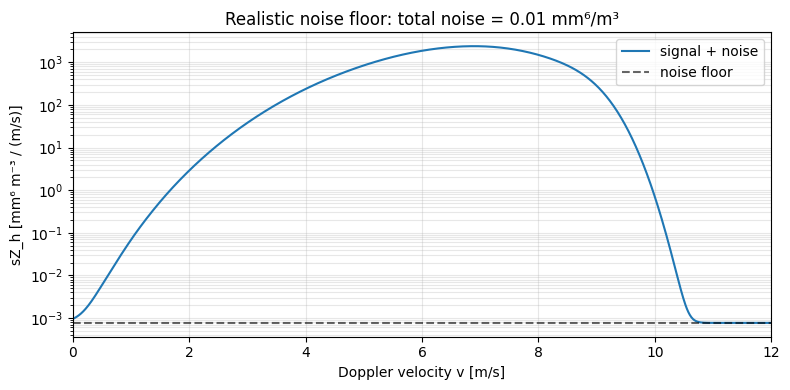

In [5]:
noisy = SpectralIntegrator(
    rain,
    fall_speed=spectra.fall_speed.atlas_srivastava_sekhon_1973,
    turbulence=spectra.GaussianTurbulence(0.3),
    v_min=-1.0, v_max=12.0, n_bins=1024,
    geometry_backscatter=geom_vert_back,
    noise='realistic',
).run()

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(noisy.v, noisy.sZ_h, 'C0-', label='signal + noise')
ax.axhline(noisy.noise_h / (noisy.v[-1] - noisy.v[0]),
           color='k', ls='--', alpha=0.6, label='noise floor')
ax.set_xlim(0, 12)
ax.set_xlabel('Doppler velocity v [m/s]')
ax.set_ylabel('sZ_h [mm⁶ m⁻³ / (m/s)]')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
ax.set_title(f'Realistic noise floor: total noise = {noisy.noise_h:.3g} mm⁶/m³')
fig.tight_layout();


## Bulk ↔ spectrum round-trip

`SpectralResult.collapse_to_bulk()` integrates S_spec and Z_spec over
velocity, yielding a Scatterer-shaped shim that the bulk `radar.*`
helpers read. Non-linear observables (Z_dr, ρ_hv) must be derived
from the *summed* matrices — not from averaging the spectral values.


In [6]:
res = run_config(spectra.GaussianTurbulence(0.3))
bulk = res.collapse_to_bulk()
rain.set_geometry(geom_vert_back)
print(f'Z_h  spectrum = {10*np.log10(radar.refl(bulk)):.3f} dBZ   '
      f'bulk = {10*np.log10(radar.refl(rain)):.3f} dBZ')
print(f'Z_dr spectrum = {10*np.log10(radar.Zdr(bulk)):+.3f} dB    '
      f'bulk = {10*np.log10(radar.Zdr(rain)):+.3f} dB')
print(f'ρ_hv spectrum = {radar.rho_hv(bulk):.5f}      '
      f'bulk = {radar.rho_hv(rain):.5f}')


Z_h  spectrum = 38.546 dBZ   bulk = 38.546 dBZ
Z_dr spectrum = +0.000 dB    bulk = +0.000 dB
ρ_hv spectrum = 1.00000      bulk = 1.00000
